<a href="https://colab.research.google.com/github/janpeter19/BPL_TEST2_Batch/blob/main/BPL_TEST2_Batch_oms_colab_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BPL_TEST2_Batch script with OMSimulator

The key library OMSimulator is installed.

After the installation a small application BPL_TEST2_Batch is loaded and run. You can continue with this example if you like.

In [1]:
!lsb_release -a # Actual VM Ubuntu version used by Google

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 24.04.5 LTS
Release:	24.04
Codename:	noble


In [2]:
!python --version

Python 3.13.16


In [3]:
!pip install OMSimulator

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for OMSimulator: filename=omsimulator-3.0.0.post198-py3-none-any.whl size=3621137 sha256=2a6819931ad83638de16e95ab2a0c4dffcd8fb422dc5747a26da7239e778b6cc
  Stored in directory: /root/.cache/pip/wheels/b4/38/7c/6483f45ae55886aa9961748ff680c86fb1a1ecc6a18f64e7b5
Successfully built OMSimulator


In [4]:
!pip install git+https://github.com/janpeter19/FMU_explore.git

  Cloning https://github.com/janpeter19/FMU_explore.git to /tmp/pip-req-build-4pck64pg
  Running command git clone --filter=blob:none --quiet https://github.com/janpeter19/FMU_explore.git /tmp/pip-req-build-4pck64pg
  Resolved https://github.com/janpeter19/FMU_explore.git to commit 1fef8e9379efbe2746dfff5c38f3c18c31ac3360
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fmu_explore: filename=fmu_explore-1.2.7-py3-none-any.whl size=30476 sha256=c9a44ce0c51f0e96b17d14e69e2f0a623d54decc78ac520b4659fb148b2e74a7
  Stored in directory: /tmp/pip-ephem-wheel-cache-nnthojkb/wheels/98/33/d9/8669158b0d845b084c49212b2330ad684e92d7a9ac84fcea8d
Successfully built fmu_explore


In [5]:
!pip install DyMat

  Preparing metadata (setup.py) ... done
  Created wheel for DyMat: filename=dymat-0.7-py3-none-any.whl size=19077 sha256=24226f93137b34adde60b6b9f0028f23beef7d15abaf5fe21d1e7d6c3639eda5
  Stored in directory: /root/.cache/pip/wheels/bd/8e/7a/d63cada988615a826eedc5353c397a21762db0633d8372d7e3
Successfully built DyMat


# BPL_TEST2_Batch setup


Now specific installation and the run simulations. Start with connecting to Github. Then upload the two files:

* FMU - BPL_TEST2_Batch_linux_om_me.fmu
* Setup-file - BPL_TEST2_Batch_oms.py
* Setup-file - BPL_TEST2_Batch_oms_explore.py

In [6]:
%%bash
git clone https://github.com/janpeter19/BPL_TEST2_Batch

Cloning into 'BPL_TEST2_Batch'...


In [7]:
%cd BPL_TEST2_Batch

/content/BPL_TEST2_Batch


In [8]:
# Import the application model and context variables
from BPL_TEST2_Batch_oms import*

Linux - run FMU pre-compiled OpenModelica


In [9]:
# Import the general FMU_explore functions ana adapt them to the application
from fmu_explore_oms import AdaptWith

Application = AdaptWith(parValue, parLocation, parCheck, \
                        fmu_model, fmu_process_diagram, \
                        MSL_usage, MSL_version, BPL_version, \
                        options, simulationTime, timeDiscreteStates, \
                        diagrams, ax, lines)

par = Application.par
init = Application.init
#simu = Application.simu
show = Application.show

resetPen = Application.resetPen
process_diagram = Application.process_diagram

describe_MSL = Application.describe_MSL
FMU_explore_info = Application.FMU_explore_info
system_info = Application.system_info
SDG = Application.SDG

In [10]:
run -i BPL_TEST2_Batch_oms_explore.py


Model for the process has been setup. Key commands:
 - par()       - change of parameters and initial values
 - init()      - change initial values only
 - simu()      - simulate and plot
 - newplot()   - make a new plot
 - show()      - show plot from previous simulation
 - disp()      - display parameters and initial values from the last simulation
 - describe()  - describe culture, broth, parameters, variables with values/units

Note that both disp() and describe() takes values from the last simulation
and the command process_diagram() brings up the main configuration

Brief information about a command by help(), eg help(simu)
Key system information is listed with the command system_info()


In [11]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [25/2.54, 20/2.54]

In [12]:
import warnings
warnings.filterwarnings("ignore")

## BPL_TEST2_Batch - demo

No processDiagram.png file in the FMU, but try the file on disk.


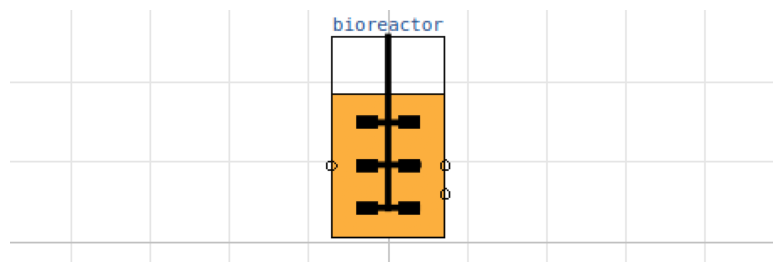

In [13]:
process_diagram()

In [14]:
describe('process')


Batch cultivation


In [15]:
Application.model.terminate()

AttributeError: 'NoneType' object has no attribute 'encode'

In [16]:
Application.model.delete()

AttributeError: 'NoneType' object has no attribute 'encode'

In [17]:
Application.restart()

In [18]:
import OMSimulator as oms

In [27]:
import DyMat

In [28]:
def simu(simulationTime=None, options=None):
    """Simulation of model and plot of results"""

    model = Application.model

    if simulationTime is None:
        simulationTime = Application.simulationTime

    if options is None:
        options = Application.options

    diagrams = Application.diagrams
    ax = Application.ax
    linecycler = Application.linecycler

    parValue = Application.parValue
    parLocation = Application.parLocation

    # Prepare for simulation
    #if not isinstance(model, oms.fmu.FMU):
    #    model = oms.FMU(Application.fmu_model)
    #    Application.model = model
    #    print('Made new model')
    model.instantiate()

    # Set options for the result file and more
    model.setResultFile('sim_res.mat')
    if options is not None:
        for command in options:
            eval(command)

    # Set parameters
#      model.reset()
    for key in parValue.keys():
        model.setValue(parLocation[key], parValue[key])
    model.setStopTime(simulationTime)

    # Simulation
    model.initialize()
    model.simulate()
    Application.model = model

    # Open up result file
    temp = scipy.io.loadmat('sim_res.mat')
    t = temp['data_2'][0];
    sim_res = DyMat.DyMatFile('sim_res.mat')
    Application.t = t
    Application.sim_res = sim_res

    # Plot results
    linetype = next(linecycler)
    context = locals().copy()

    for command in diagrams:
        eval(command, {}, context)

    # Close the model
    model.terminate()
    model.delete()

In [21]:
isinstance(Application.model, oms.FMU)

True

In [23]:
Application.model.terminate()

RuntimeError: Failed to terminate model: Status.error

In [30]:
Application.model.delete()

In [31]:
Application.model = oms.FMU(fmu_model)

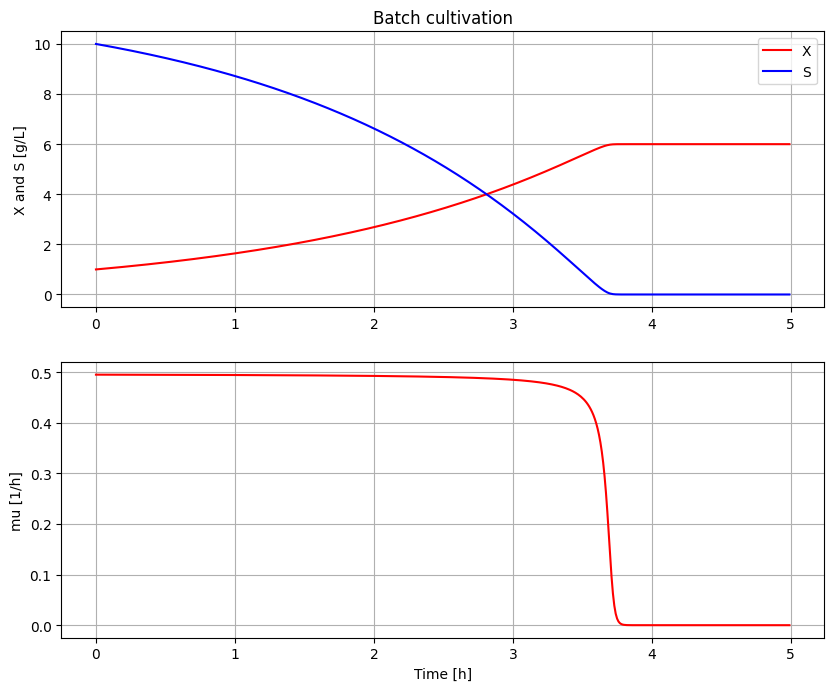

In [32]:
# Simulation with default values of the process
newplot(plotType='TimeSeries')
simu()

In [33]:
isinstance(Application.model, oms.FMU)

True

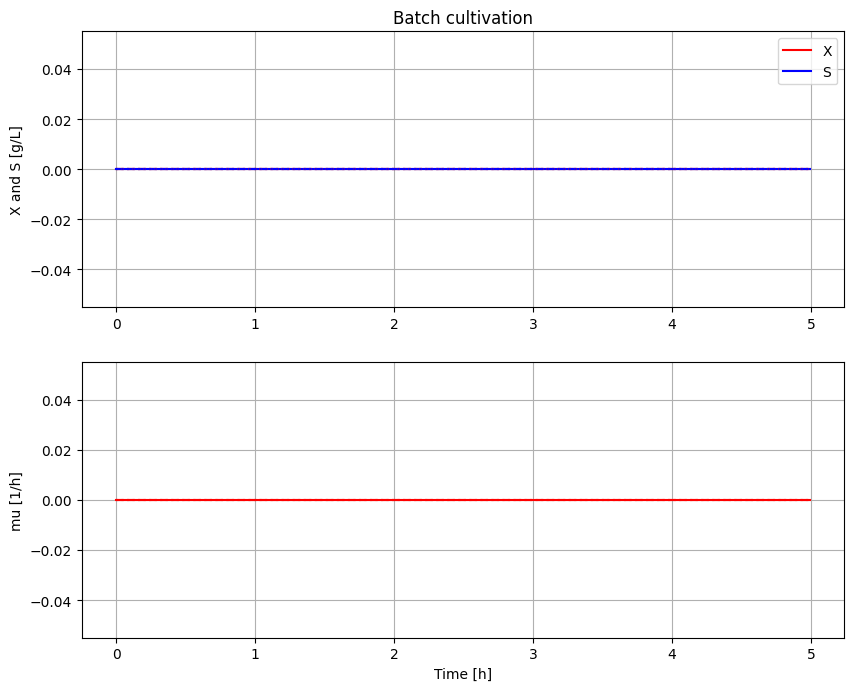

In [34]:
# Simulation were initial value of biomass VX_0 is varied
newplot(plotType='TimeSeries')
for value in [1.0, 0.7, 1.3]:
  init(VX_start=value)
  simu()

# Restore default value of VX_start
init(VX_start=1.0)

In [ ]:
# Simulation were initial value of substrate VS_0 is varied
newplot(plotType='TimeSeries')
for value in [10, 7, 13]:
  init(VS_start=value)
  simu()

# Restore default value of VS_start
init(VS_start=10)

In [ ]:
describe('MSL')

In [ ]:
system_info()

In [ ]:
!lsb_release -d

In [ ]:
SDG()

In [ ]:
Application.model.getValue('bioreactor.V')

In [ ]:
Application.restart()

In [ ]:
newplot()
simu()

In [ ]:
Application.model.terminate()

In [ ]:
Application.model.delete()

In [ ]:
Application.restart()

In [ ]:
#----------------------------------------

In [ ]:
import OMSimulator as oms

In [ ]:
model = oms.FMU(fmu_model)

In [ ]:
isinstance(model, oms.fmu.FMU)

In [ ]:
model.instantiate()

In [ ]:
for key in parValue.keys():
  model.setValue(parLocation[key], parValue[key])
model.setStopTime(simulationTime)

In [ ]:
model.initialize()
model.simulate()

In [ ]:
model.terminate()

In [ ]:
model.delete()

In [ ]:
Application.restart()